# Imports

In [15]:
from torch.utils.data import DataLoader, random_split
import torch
from data import PermutationDataset
from model import PermutationModel
from train import train_one_epoch, evaluate_model
import matplotlib.pyplot as plt

# Parameters
This includes parameters for what to train on and predict, and also the hyperparameters for training.

In [16]:
n = 9
label_name = "stat2"
layers = [2]

epochs = 100
train_split, test_split = 0.8, 0.2
learning_rate = 0.001
momentum = 0.9
batch_size = 64

# Initialization
Initialize the data loaders, model, loss function, optimizers.

In [17]:
full_dataset = PermutationDataset(n, label_name)
training_dataset, test_dataset = random_split(full_dataset, [train_split, test_split])
model = PermutationModel(n, layers)
loss_fn = torch.nn.CrossEntropyLoss(full_dataset.class_weights())
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)
training_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
losses = []

# Training loop
Train the model for the appropriate number of epochs and then save the model in `models`.

In [18]:
for epoch in range(epochs):
    model.train(True)
    current_loss = train_one_epoch(training_loader, model, loss_fn, optimizer)
    print(f"Epoch {epoch}, Loss {current_loss}")
    losses.append(current_loss)

torch.save(model.state_dict(), f"models/{label_name}_{n}.pt")

Epoch 0, Loss 305.2251807153225
Epoch 1, Loss 228.0747739970684
Epoch 2, Loss 185.30714935064316
Epoch 3, Loss 158.5087510049343
Epoch 4, Loss 140.04199144244194
Epoch 5, Loss 126.42708268761635
Epoch 6, Loss 115.89322665333748
Epoch 7, Loss 107.43672953546047
Epoch 8, Loss 100.4644482433796
Epoch 9, Loss 94.58743995428085
Epoch 10, Loss 89.55154886841774
Epoch 11, Loss 85.17302529513836
Epoch 12, Loss 81.32233445346355
Epoch 13, Loss 77.89811190217733
Epoch 14, Loss 74.83446348458529
Epoch 15, Loss 72.06733334809542
Epoch 16, Loss 69.55225235968828
Epoch 17, Loss 67.25348386913538
Epoch 18, Loss 65.14398487657309
Epoch 19, Loss 63.19477481395006
Epoch 20, Loss 61.3949466124177
Epoch 21, Loss 59.718720346689224
Epoch 22, Loss 58.15364049375057
Epoch 23, Loss 56.68927516788244
Epoch 24, Loss 55.3191631808877
Epoch 25, Loss 54.027364529669285
Epoch 26, Loss 52.81006985157728
Epoch 27, Loss 51.66089294850826
Epoch 28, Loss 50.571716740727425
Epoch 29, Loss 49.53867296874523
Epoch 30, Loss

# Print the loss curve
Visualize the loss curve to ensure that the model is learning correctly. Save the loss curve in `figures/` so that you can refer to them later.

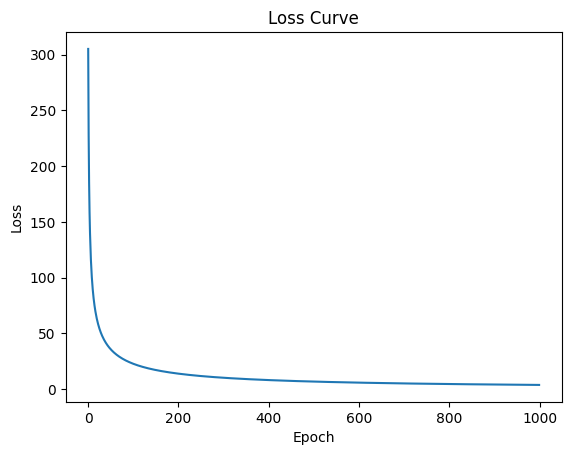

In [19]:
# TODO
# Create a figure and axis
fig, ax = plt.subplots()

# Plot the loss curve
ax.plot(range(len(losses)), losses)

# Add labels and title
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Loss Curve')

fig.savefig(f'figures/loss_curve_stat2_{n}.png', dpi=300)
# Show the plot
plt.show()

# Evaluate the model
Compute the confusion matrix on the train and test dataset and print out the accuracy and plot the confusion matrix.

In [20]:
# TODO
confusion_matrix = evaluate_model(model, test_dataset)
confusion_matrix.print_accuracy()

Accuracy for class 0 = 100.0%
Accuracy for class 1 = 100.0%
Overall accuracy = 100.0%


# Plot model weights and connections.
Plot the model weights and connections in order to attempt to interpret what the model is learning.

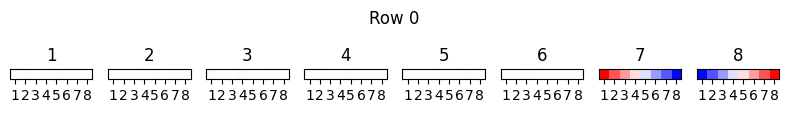

In [21]:
model.plot_heatmap_feature(0,0)